In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import pickle
from tqdm import tqdm

# Format Common Voice 9 


Load full corpora word alignments and pair with metadata to generate manifests for train, val, and test splits.

cv_all_word_alignments dataframe has fields:
* aud_path
* client_id
* gender
* origin_index
* word
* start_in_s
* end_in_s
* sr

Fields to add:
* dataset split (integer: 0=train, 1=valid, 2=test)
* word int label
* label talker sex int (integer: 0=female, 1=male, 2=other/intersex)


Commonvoice does not natively support speakerr identification, as the set of talkers in a given split (train,dev,test) are unique. We can create our own version if necessary.

We will filter for approximage speaker and gender balancing withtin splits. Will need to check if speakers are unique to train test val. If not, we will want to create a set with unique speakers per split. 


In [2]:
commonvoice_path = Path('/scratch2/weka/mcdermott/imgriff/datasets/commonvoice_9/en/')


In [3]:
word_level_manifest = pd.read_pickle(commonvoice_path / "cv_all_word_alignments.pdpkl")

In [4]:
word_level_manifest.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr
0,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,THE,0.302125,0.402813,32000
1,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GROUP,0.423000,0.664687,32000
2,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,WAS,0.745250,0.886250,32000
3,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,ULTIMATELY,1.027250,1.389812,32000
4,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,NOT,1.470375,1.651687,32000


### Load list of talkers in each split

In [5]:
# convert to set for fast lookup

train_names = set(pd.read_csv(commonvoice_path / 'train.tsv', sep='\t',
                          usecols=['client_id'])['client_id'].unique())

val_names = set(pd.read_csv(commonvoice_path / 'dev.tsv',
                               sep='\t', usecols=['client_id'])['client_id'].unique())

test_names = set(pd.read_csv(commonvoice_path / 'test.tsv', sep='\t',
                         usecols=['client_id'])['client_id'].unique())




In [6]:
train_names.intersection(val_names)

set()

In [7]:
train_names.intersection(test_names)

set()

In [8]:
val_names.intersection(test_names)

set()

##### Find which split  each talker is in

In [9]:
def assign_to_split(talker,
                    train_names=train_names,
                    val_names=val_names,
                    test_names=test_names):
 
    if talker in train_names:
        data_split_str = 'train'
        data_split_int = 0
    elif talker in val_names:
        data_split_str = 'val'
        data_split_int = 1
    elif talker in test_names:
        data_split_str = 'test'
        data_split_int = 2
    else:
        return float('nan'), float('nan')
    return data_split_str, data_split_int


talkers = word_level_manifest['client_id'].unique()

splits = {talker:assign_to_split(talker) for talker in tqdm(talkers)}
# splits = {talker:split_data for talker, split_data in splits.items() if split_data!=None}
    

100%|██████████| 47819/47819 [00:00<00:00, 336323.89it/s]


In [10]:
split_str, split_int = zip(*word_level_manifest['client_id'].map(splits).values)

word_level_manifest['dataset_splits'] = split_str
word_level_manifest['dataset_split_int'] = split_int



In [11]:
# word_level_manifest = word_level_manifest.dropna(subset=['dataset_splits'])

In [12]:
# word_level_manifest['dataset_split_int'] = word_level_manifest['dataset_split_int'].astype('int', copy=False)

## 

In [13]:
word_level_manifest.dataset_splits.value_counts(dropna=False)

train    9217125
NaN      3183693
test      172302
val       101076
Name: dataset_splits, dtype: int64

In [14]:
word_level_manifest.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int
0,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,THE,0.302125,0.402813,32000,train,0.0
1,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GROUP,0.423000,0.664687,32000,train,0.0
2,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,WAS,0.745250,0.886250,32000,train,0.0
3,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,ULTIMATELY,1.027250,1.389812,32000,train,0.0
4,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,NOT,1.470375,1.651687,32000,train,0.0


### Get WSN/jSIN vocabulary

In [15]:
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

word_to_ix = {value.upper():int(key) for key, value in class_map.items()
             }
vocab = [word.upper() for word in class_map.values() if '__null' not in word]  # [1:] to cut '__nullSignal__'


#### Add word ints 

In [16]:
word_level_manifest['word_int'] = word_level_manifest['word'].map(word_to_ix)

In [17]:
word_level_manifest.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,word_int
0,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,THE,0.302125,0.402813,32000,train,0.0,NaN
1,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GROUP,0.423000,0.664687,32000,train,0.0,305.0
2,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,WAS,0.745250,0.886250,32000,train,0.0,NaN
3,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,ULTIMATELY,1.027250,1.389812,32000,train,0.0,NaN
4,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,NOT,1.470375,1.651687,32000,train,0.0,NaN


### Save unfiltered manifest with added data


In [18]:
# word_level_manifest.to_pickle(commonvoice_path / "cv_all_word_alignments_with_labels.pdpkl")

### Look at balence of unfiltered data

These are the commonvoice words, not the wsn vocabulary

<AxesSubplot:>

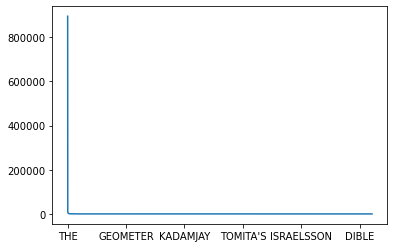

In [19]:
counts = word_level_manifest.word.value_counts(normalize=False)
counts.plot()

In [20]:
counts[:1000] #* len(word_level_manifest.word.unique())

THE         895516
OF          320059
A           300852
AND         277850
TO          269457
             ...  
NETWORK       1385
CUT           1383
SEPARATE      1381
FIGHT         1380
JAPAN         1380
Name: word, Length: 1000, dtype: int64

(0.0, 30000.0)

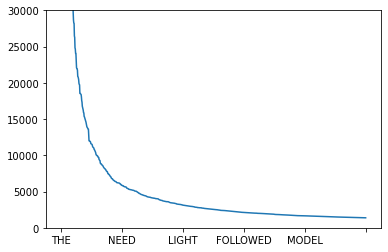

In [21]:
# top 1k 
import matplotlib.pyplot as plt
top_1k = counts[:1000]
top_1k_vocab = top_1k.index #* len(word_level_manifest.word.unique())
top_1k.plot()
plt.ylim(0,30000)

In [22]:
# new_words = word_level_manifest[word_level_manifest.word.isin(top_1k_vocab)].copy()

### Balance is poor - need to compute new vocab

Steps:
1. gender balance
2. compute most frequent words common to train, val, test
3. word frequency balance
4. talker balance

Start with `word_level_manifest`!!! 

### Gender balance

In [23]:
# Take same number of males as females
np.random.seed(0)

samples_per_gender = {gender:count for gender,count in word_level_manifest.gender.value_counts().items()}
samples_per_gender['male'] = samples_per_gender['female'] 
print(samples_per_gender)
gend_bal_new = word_level_manifest.groupby('gender').apply(lambda group: group.sample(samples_per_gender[group.name]))
gend_bal_new = gend_bal_new.reset_index(drop=True)


{'male': 2202050, 'female': 2202050, 'other': 272644}


### word balance

To find our vocabulary:
1. Compute word frequency in each subset of commonvoice
2. Rank by frequency in the training set.  
3. Limit vocabulary such that:
    * least frequent word occurs at least 100 times in the training
    * occurs at least once in both test and val set 

We will then balance word occurances in the training set by taking at most 5,000 occurances of each word via random sample without replacement.  

In [305]:
# get ordered word frequency in each split of the dataset 

word_balance_df = gend_bal_new.groupby(
    'dataset_splits').word.value_counts().unstack().T.dropna().sort_values('train', ascending=False)

In [306]:
# word_balance_df = word_balance_df[word_balance_df.mean(axis=1) > 50]

In [307]:
# look at range of specific words 
word_balance_df.iloc[[0,10,990,1000]]

dataset_splits,test,train,val
word,,,
THE,767.0,274433.0,528.0
FOR,87.0,31402.0,68.0
WELLKNOWN,2.0,195.0,1.0
MILLION,1.0,188.0,3.0


1066

In [95]:
### Get vocab of top 1k words - df is already sorted 

cv_vocab = set(word_balance_df[:1000].index)

In [97]:
# filter for words in vocab 

gend_bal_filt = gend_bal_new[gend_bal_new.word.isin(cv_vocab)]

In [98]:
### look at new word frequency across dataset 
gend_bal_filt.word.value_counts()

THE           330254
OF            122041
A             110394
AND           103863
TO             94867
               ...  
LABOUR           208
ASIAN            208
POWERS           208
RETIREMENT       203
RESISTANCE       192
Name: word, Length: 1000, dtype: int64

In [101]:
word_balance_df['test']['THE']

767.0

In [109]:
### Actual word balancing happens here 

upper_lim = 5000
np.random.seed(0)


# samples_per_word = {word:(count if count < upper_lim else upper_lim)
#                     for word,count in gend_bal_filt.word.value_counts().items()}

def get_n_words(split, word, upper_lim=upper_lim):
    count = word_balance_df[split][word]
    if count > upper_lim:
        return int(upper_lim)
    else:
        return int(count)
    
word_gen_bal = gend_bal_filt.groupby(
                        ['dataset_splits','word']).apply(
                        lambda group: group.sample( 
                            get_n_words(group.name[0], group.name[1])))

word_gen_bal = word_gen_bal.reset_index(drop=True)




In [110]:
word_gen_bal

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,word_int
0,common_voice_en_671188.mp3,bc42a609c4c835a7ebcd3ed870258b842b0b5c05534256...,male,3521,A,4.005250,4.025313,48000,test,2.0,NaN
1,common_voice_en_19672834.mp3,cb584d113aa586a972128ded6e5afe6d6e1e49e0d63d33...,male,14009,A,3.423313,3.443313,48000,test,2.0,NaN
2,common_voice_en_20890437.mp3,8147f8452a0bfe11d6e660969ca4a59ba10eb4b33f705e...,male,10682,A,1.901687,2.001750,48000,test,2.0,NaN
3,common_voice_en_23835038.mp3,29ea7b37aa5b4e6d7dfed3c96938d4c7e8de7b64fd03dd...,male,21143,A,2.725875,2.846125,48000,test,2.0,NaN
4,common_voice_en_17485893.mp3,24f4e4e56434caf99b62ef4486121e99f9cc4df6d53dd6...,male,20584,A,0.843875,0.944312,48000,test,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1199481,common_voice_en_169996.mp3,ff927a42a058b034bd221ab024d84f7c84ab3a1cccf91b...,male,46574,YOUR,3.570125,3.770688,48000,val,1.0,NaN
1199482,common_voice_en_673977.mp3,550058a67e8bc5a66e6d2bebc64ac4e61ec4b9b4207bb2...,female,26381,YOUR,4.802313,5.002375,48000,val,1.0,NaN
1199483,common_voice_en_17829980.mp3,3a4ec1fd6ed19a5b69141ffc89bf15153e0b6eb6be8f1a...,female,23094,YOUR,2.182937,2.363187,48000,val,1.0,NaN
1199484,common_voice_en_657450.mp3,3af0e38c640bb2dbe501ecf8e0fb2dce98ad47feffd2c0...,male,23182,YOUR,3.406062,3.626438,48000,val,1.0,NaN


In [111]:
new_word_freq = word_gen_bal.word.value_counts()
new_words = set(new_word_freq.index)
# top_1k = set(new_word_freq.index[:1000])

In [31]:
# top1_gend_bal = word_gen_bal[word_gen_bal.word.isin(top_1k)]

In [113]:
new_word_freq

THE           6295
OF            5480
A             5462
IS            5399
TO            5397
              ... 
TAIL           193
RESISTANCE     192
SOLID          191
SCRIPT         191
THINKING       190
Name: word, Length: 1000, dtype: int64

In [115]:
word_gen_bal.dataset_splits.value_counts()

train    1186568
test        7643
val         5275
Name: dataset_splits, dtype: int64

In [116]:
word_gen_bal.gender.value_counts()

female    574220
male      552154
other      73112
Name: gender, dtype: int64

### talker balance 

Now we sample from our talkers to impose a soft balance across voices in all datasets. We will require at least 2 utterances per talker and at most 5000. 

In [131]:
### Check talker counts
talker_counts = word_gen_bal.client_id.value_counts()

In [132]:
cutoff = 2
print("N total talkers: ", len(talker_counts))

print(f"N total talkers with more than {cutoff} utterances {len(talker_counts[talker_counts >= cutoff])}")
print("Max from a single talker: ", talker_counts[talker_counts >= cutoff].max())
print("Min from a single talker: ", talker_counts[talker_counts >= cutoff].min())

N total talkers:  10214
N total talkers with more than 2 utterances 9970
Max from a single talker:  42968
Min from a single talker:  2


In [216]:
np.random.seed(1)
upper_lim = 5000 # max num excerpts per talker
lower_lim = 2

def limit_count(count):
    if count < lower_lim:
        return 0 
    elif count > upper_lim:
        return upper_lim
    else:
        return count
        
samples_per_talker = {talker:limit_count(count)
                    for talker,count in word_gen_bal.client_id.value_counts().items()}


# draw from dataframe filtered to only have the top 1k words 
to_use = word_gen_bal[word_gen_bal.client_id.isin(set(samples_per_talker.keys()))]
talker_gend_bal = to_use.groupby('client_id').apply(lambda group: group.sample(samples_per_talker[group.name]))
talker_gend_bal = talker_gend_bal.reset_index(drop=True)


In [217]:
### Check word count after talker balance
fin_word_freq = talker_gend_bal.word.value_counts()
cv_words = set(fin_word_freq.index)
top_1k = set(fin_word_freq.index[:1000])

In [218]:
### Check dataset split sizes
talker_gend_bal.dataset_splits.value_counts()

train    995058
test       7479
val        5269
Name: dataset_splits, dtype: int64

In [235]:
### Check gender balance

talker_gend_bal.groupby('dataset_splits').gender.value_counts()

dataset_splits  gender
test            male        4608
                female      2588
                other        283
train           male      479408
                female    467179
                other      48471
val             male        3106
                female      2040
                other        123
Name: gender, dtype: int64

In [220]:
### Final word balance across dattasets

# get ordered word frequency in each split of the dataset 

fin_word_balance_df = talker_gend_bal.groupby(
    'dataset_splits').word.value_counts().unstack().T.sort_values('train', ascending=False)

In [297]:
fin_word_balance_df[:1000]

dataset_splits
test       1.0
train    155.0
val        1.0
dtype: float64

In [257]:
### Get final counts after selecting for valid words
final_vocab = set(fin_word_balance_df.dropna().index)

final_df = talker_gend_bal[talker_gend_bal.word.isin(final_vocab)]


In [298]:
# Final word balance 

final_df.groupby(
    'dataset_splits').word.value_counts().unstack().T.sort_values('train', ascending=False).test.median()


2.0

In [299]:
final_df.client_id.unique().shape

(9970,)

In [269]:
## Final gender balance 

final_df.groupby('dataset_splits').gender.value_counts(normalize=True)

dataset_splits  gender
test            male      0.616022
                female    0.346128
                other     0.037849
train           male      0.481810
                female    0.469474
                other     0.048716
val             male      0.589700
                female    0.386925
                other     0.023375
Name: gender, dtype: float64

In [263]:
### Final talker occurances 
final_df.groupby(
    'dataset_splits').client_id.value_counts().unstack().T.max()


dataset_splits
test       31.0
train    4993.0
val        38.0
dtype: float64

In [264]:
### Final dataset split sizes
final_df.dataset_splits.value_counts()

train    992700
test       7477
val        5262
Name: dataset_splits, dtype: int64

### Get balance of talkers in training set 


In [287]:
talkers = final_df[final_df.dataset_splits=='train'].client_id.value_counts()

In [288]:
talkers.shape, talkers[talkers>=1000].sum()/talkers.sum(), talkers[talkers<1000].sum()/talkers.sum(),  talkers[talkers<1000].shape

((8173,), 0.41303112722877, 0.58696887277123, (7998,))

## Alternate set

In [311]:
# Take same number of males as females

samples_per_gender = {gender:count for gender,count in gend_bal_new.gender.value_counts().items()}
samples_per_gender['male'] = samples_per_gender['female'] 
# print(samples_per_talker)
word_bal_gend_bal_new = gend_bal_new.groupby('gender').apply(lambda group: group.sample(samples_per_gender[group.name]))
word_bal_gend_bal_new = word_bal_gend_bal_new.reset_index(drop=True)


## Cut to exclude out of vocabulary excerpts 

In [312]:
valid_manifest = word_level_manifest.dropna(subset=['word_int'])

In [313]:
valid_manifest['word_int'] = valid_manifest['word_int'].astype('int', copy=False)

/tmp/ipykernel_39514/1424092925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_manifest['word_int'] = valid_manifest['word_int'].astype('int', copy=False)


## Look at balance post cutting oovs and unplaced talkers

In [314]:
# dataset split
valid_manifest.dataset_splits.value_counts(dropna=False)

train    1517148
NaN       404747
test       25971
val        15868
Name: dataset_splits, dtype: int64

In [129]:
commonvoice_path

PosixPath('/scratch2/weka/mcdermott/imgriff/datasets/commonvoice_9/en')

In [315]:
valid_manifest.groupby('dataset_splits').gender.value_counts(dropna=False)

dataset_splits  gender
test            NaN        22215
                male        3066
                female       625
                other         65
train           male      802300
                NaN       364311
                female    311254
                other      39283
val             NaN        13401
                male        1995
                female       449
                other         23
Name: gender, dtype: int64

In [127]:
valid_manifest.to_pickle(commonvoice_path / "cv_word_alignments_with_labels_no_wsn_oov.pdpkl")

In [128]:
!ls {commonvoice_path}

alignment_dfs
clips
cv_all_alignments_pre_cut.pdpkl
cv_all_word_alignments.pdpkl
cv_all_word_alignments_with_labels.pdpkl
cv_gender_balanced_word_alignments_with_labels.pdpkl
cv_test_set_wsn_vocab_word_alignments.pdpkl
cv_test_set_wsn_vocab_word_alignments_gender_balanced.pdpkl
cv_test_set_wsn_vocab_word_alignments_gender_balanced_48kHz_sr.pdpkl
cv_test_set_wsn_vocab_word_alignments_gender_balanced_all_sr.pdpkl
cv_word_alignments_with_labels_no_wsn_oov.pdpkl
dev.tsv
invalidated.tsv
other.tsv
reported.tsv
test.tsv
train.tsv
validated.tsv


In [97]:
%matplotlib inline
import seaborn as sns

<AxesSubplot:>

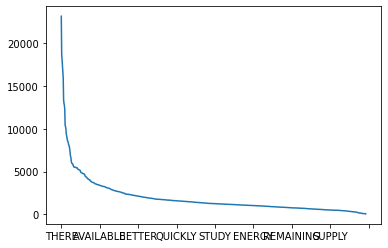

In [98]:
## Plot word frequency



valid_manifest[valid_manifest.dataset_splits =='train'].word.value_counts().plot()

In [103]:
folded_manifest = valid_manifest.copy()

In [104]:
folded_manifest['dataset_splits'][folded_manifest['dataset_splits'].isna()] = 'train'

/tmp/ipykernel_23052/412571450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  folded_manifest['dataset_splits'][folded_manifest['dataset_splits'].isna()] = 'train'


In [105]:
folded_manifest

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,word_int
1,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GROUP,0.423000,0.664687,32000,train,0.0,305
5,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GIVEN,1.692000,1.933688,32000,train,0.0,297
14,common_voice_en_25124753.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341006,RECEIVED,1.824750,2.205750,32000,train,0.0,576
17,common_voice_en_25124753.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341006,NATIONAL,2.426312,2.787313,32000,train,0.0,445
18,common_voice_en_25124753.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341006,PRESS,2.847437,3.068000,32000,train,0.0,528
...,...,...,...,...,...,...,...,...,...,...,...
12674151,common_voice_en_17406466.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263501,MIGHT,6.577375,6.777875,48000,train,NaN,427
12674165,common_voice_en_17406468.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263503,NEARLY,1.842313,2.302938,48000,train,NaN,449
12674172,common_voice_en_17406468.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263503,THEIR,5.487000,5.627187,48000,train,NaN,712
12674175,common_voice_en_17406469.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263504,COULD,1.643063,1.803375,48000,train,NaN,167


<AxesSubplot:>

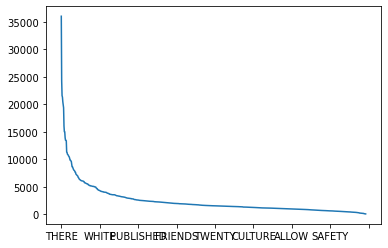

In [106]:
folded_manifest[folded_manifest.dataset_splits =='train'].word.value_counts().plot()

In [107]:
folded_manifest[folded_manifest.dataset_splits =='train'].word.value_counts()


THERE         36050
THEIR         24293
AFTER         21594
FIRST         21318
OTHER         20445
              ...  
SEVENTY          81
INFLATION        75
SECURITIES       71
SPOKESMAN        69
ANALYSTS         41
Name: word, Length: 793, dtype: int64

## Gender balance then compare distributions

In [317]:
valid_manifest.gender.value_counts(dropna=False)

male      961689
NaN       603985
female    354439
other      43621
Name: gender, dtype: int64

In [319]:
# Take same number of males as females

samples_per_gender = {gender:count for gender,count in valid_manifest.gender.value_counts().items()}
samples_per_gender['male'] = samples_per_gender['female'] 
# print(samples_per_talker)
valid_gender_balanced_manifest = valid_manifest.groupby('gender').apply(lambda group: group.sample(samples_per_gender[group.name]))
valid_gender_balanced_manifest = valid_gender_balanced_manifest.reset_index(drop=True)


### Look at distribution after cutting 

In [320]:
valid_gender_balanced_manifest.dataset_splits.value_counts(dropna=False)

train    646124
NaN      103303
test       1833
val        1239
Name: dataset_splits, dtype: int64

<AxesSubplot:>

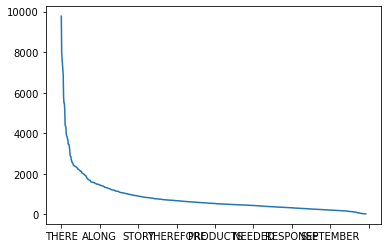

In [321]:
valid_gender_balanced_manifest[valid_gender_balanced_manifest.dataset_splits =='train'].word.value_counts().plot()

In [322]:
valid_gender_balanced_manifest[valid_gender_balanced_manifest.dataset_splits =='train'].word.value_counts().min()

22

#### Cut to exclude unassigned talkers and save

These likely failed common voices validation & quality control criteria 

In [125]:
valid_gender_balanced_manifest = valid_gender_balanced_manifest.dropna(subset=['dataset_splits'])

In [126]:
valid_gender_balanced_manifest.to_pickle(commonvoice_path / "cv_gender_balanced_word_alignments_with_labels.pdpkl")